In [204]:
import os
import geopandas as gpd
from osgeo import gdal, ogr, osr
import numpy as np
import rasterio
from rasterio.mask import mask
from shapely.geometry import Polygon, MultiPolygon, shape
from shapely.ops import unary_union
import pandas as pd
import seaborn as sns
import json

# Required File Doc
input_raster = "../USGS_Raster/raw_raster/L2SP_013032_20250416_20250418.TIF"
clip_geojson = "../USGS_Raster/Borough.geojson"
clipped_raster = "../USGS_Raster/nyc_raster/20250416.tif"

## Clip the input raster to the geographic extent of NYC

In [208]:
# Read the Raster Data
with rasterio.open(input_raster) as src:
    gdf_clip = gpd.read_file(clip_geojson)
    gdf_clip = gdf_clip.to_crs(src.crs)  # Project gdf_clip using the same crs as the raster data

    # Clip the raster
    clipped_image, clipped_transform = mask(src, gdf_clip.geometry, crop=True)
    clipped_meta = src.meta.copy()
    clipped_meta.update({
        "driver": "GTiff",
        "height": clipped_image.shape[1],
        "width": clipped_image.shape[2],
        "transform": clipped_transform,
        "dtype": "float32",
        "nodata": -9999.0
    })

# Write the clipped raster data into clipped_raster
os.makedirs(os.path.dirname(clipped_raster), exist_ok=True)
with rasterio.open(clipped_raster, "w", **clipped_meta) as dest:
    dest.write(np.where(np.isnan(clipped_image), -9999.0, clipped_image))

## Polygonize the raster at the pixel level and convert the result into a GeoDataFrame

Each Pixel is a 30m * 30m Square in real life.

In [209]:
# Open the clipped raster and get the first band
src_ds = gdal.Open(clipped_raster)
band = src_ds.GetRasterBand(1)

# Create an in-memory vector datasource to store polygonized features
mem_driver = ogr.GetDriverByName("Memory")
mem_ds = mem_driver.CreateDataSource("memData")

# Use the same spatial reference as the raster
srs = osr.SpatialReference()
srs.ImportFromWkt(src_ds.GetProjection())

# Create a layer and add a field to store the raster values
layer = mem_ds.CreateLayer("layer", srs=srs)
field = ogr.FieldDefn("value", ogr.OFTReal)
layer.CreateField(field)

# Polygonize the raster band and store the result in the memory layer
gdal.Polygonize(band, None, layer, 0, [], callback=None)

# Convert the in-memory OGR layer to a Geodataframe
features = []
# Iterate over each polygonized feature from the raster
for feat in layer:
    # Convert the geometry from JSON string to a shapely geometry object
    geom_json = json.loads(feat.GetGeometryRef().ExportToJson())
    geom = shape(geom_json)

    # Extract the raster value from the feature (e.g., pixel value)
    value = feat.GetField("value")

    # Only keep valid features with non-null and non-negative values
    if value is not None and value >= 0:
        features.append({
            "geometry": geom,
            "value": value
        })

# Convert the feature list into a GeoDataFrame
gdf = gpd.GeoDataFrame(features, crs=f"EPSG:{raster_epsg}")

## Compute Temperature

In [210]:
# Convert pixel DN value to temperature in Kelvin using a predefined formula
gdf["temperature_K"] = gdf["value"] * 0.00341802 + 149.0

# Convert temperature from Kelvin to Fahrenheit
gdf["temperature_F"] = (gdf["temperature_K"] - 273.15) * 9 / 5 + 32

# Clean the Noise Data that has a temperature lower than -20F
gdf = gdf[gdf['temperature_F'] >= -20]

# Preview the resulting data
gdf.head()

,geometry,value,temperature_K,temperature_F
0,"POLYGON ((591735 4529925, 591735 4529895, 5917...",38169.0,279.462405,43.362330
1,"POLYGON ((591765 4529925, 591765 4529895, 5917...",38299.0,279.906748,44.162146
2,"POLYGON ((591795 4529925, 591795 4529895, 5918...",38469.0,280.487811,45.208060
3,"POLYGON ((591825 4529925, 591825 4529895, 5918...",38582.0,280.874048,45.903286
4,"POLYGON ((591735 4529895, 591735 4529865, 5917...",38198.0,279.561528,43.540750


## Visualization Making

<Axes: xlabel='temperature_F', ylabel='Count'>

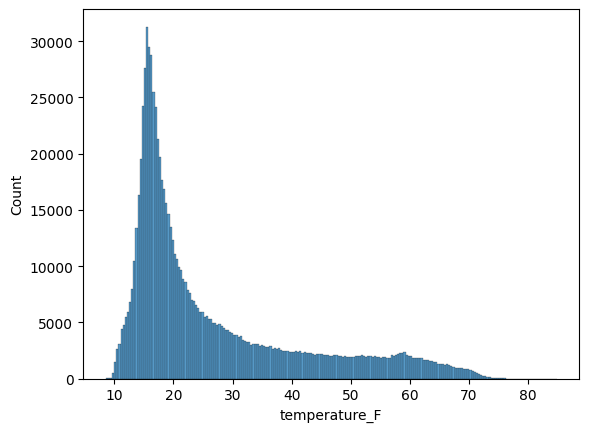

In [211]:
gdf.to_file('../USGS_Raster/Temp_data/temp_pixel.geojson', driver="GeoJSON")
sns.histplot(gdf['temperature_F'])

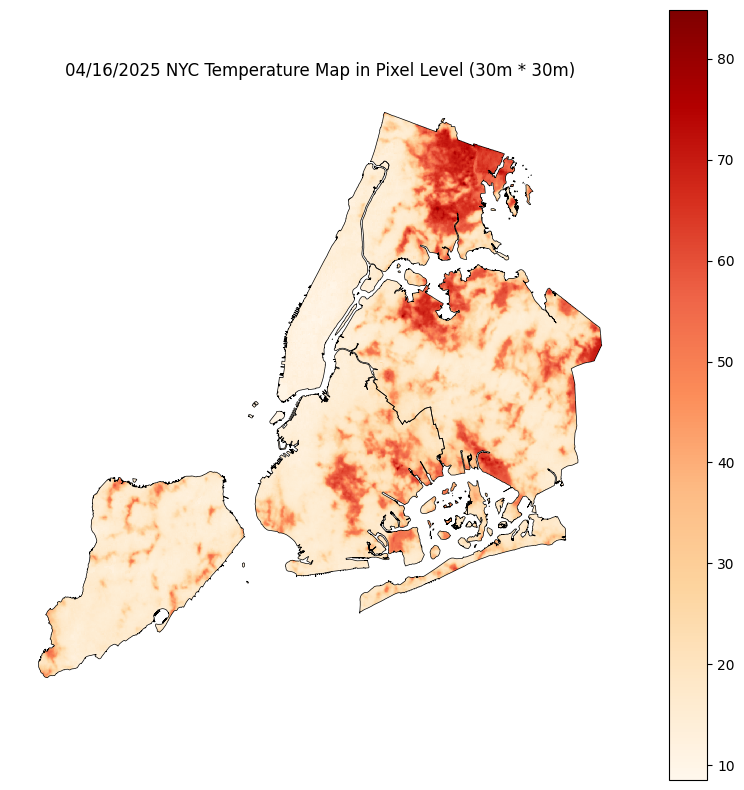

In [221]:
boundary_gdf = gpd.read_file("../USGS_Raster/Borough.geojson")
boundary_gdf = boundary_gdf.to_crs(gdf.crs)

# 创建图像
fig, ax = plt.subplots(figsize=(10, 10))

# 温度图层
gdf.plot(
    column='temperature_F',
    cmap='OrRd',
    legend=True,
    ax=ax
)

# 边界图层（透明填充 + 黑色边框）
boundary_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.5
)

# 细节修饰
plt.title("04/16/2025 NYC Temperature Map in Pixel Level (30m * 30m)")
plt.axis('off')
plt.savefig('pic.png', dpi=300, bbox_inches='tight')
plt.show()

## Census Block Level Temperature Data

In [223]:
gdf_blocks = gpd.read_file("../USGS_Raster/Block_nowater.geojson")
gdf_blocks = gdf_blocks.to_crs(gdf.crs)


# Perform a spatial intersection between pixels and census blocks
# This will clip each pixel polygon to the boundaries of the census blocks
gdf_intersect = gpd.overlay(gdf, gdf_blocks, how="intersection")


# Calculate area for each intersected polygon
# This area will be used for weighted averaging
gdf_intersect["area"] = gdf_intersect.geometry.area


# Compute area-weighted temperature
# Multiply temperature by area to get weighted value
gdf_intersect["weighted_temp"] = gdf_intersect["temperature_F"] * gdf_intersect["area"]

# Group by census block ID and sum weighted values and area
block_avg_temp = (
    gdf_intersect.groupby("geoid")[["weighted_temp", "area"]]
    .sum()
    .reset_index()
)

# Compute area-weighted average temperature for each block
block_avg_temp["temperature_F"] = block_avg_temp["weighted_temp"] / block_avg_temp["area"]

# Keep only necessary columns
block_avg_temp = block_avg_temp[["geoid", "temperature_F"]]

# Join the aggregated results back to the census block geometries
gdf_result = gdf_blocks.merge(block_avg_temp, on="geoid", how="left")
gdf_result.to_file("../USGS_Raster/Temp_data/temp_block.geojson", driver="GeoJSON")
gdf_result.head()


,shape_area,shape_leng,boroname,ct2020,borocode,cb2020,bctcb2020,geoid,geometry,temperature_F
0,1202838.17013,6437.85374521,Manhattan,000100,1,1000,10001001000,360610001001000,"MULTIPOLYGON (((581106.119 4505997.085, 581148...",13.166790
1,640166.352288,4395.19018343,Manhattan,000100,1,1001,10001001001,360610001001001,"MULTIPOLYGON (((580787.267 4504805.375, 580819...",11.189412
2,129276.332277,1569.3848232,Manhattan,000201,1,1000,10002011000,360610002011000,"MULTIPOLYGON (((585722.289 4507480.709, 585558...",13.022846
3,139360.445114,1594.26285534,Manhattan,000201,1,1001,10002011001,360610002011001,"MULTIPOLYGON (((585727.959 4507402.057, 585695...",12.679246
4,263308.43936,2055.29596105,Manhattan,000201,1,2000,10002012000,360610002012000,"MULTIPOLYGON (((585737.948 4507321.994, 585747...",13.091170


<Axes: xlabel='temperature_F', ylabel='Count'>

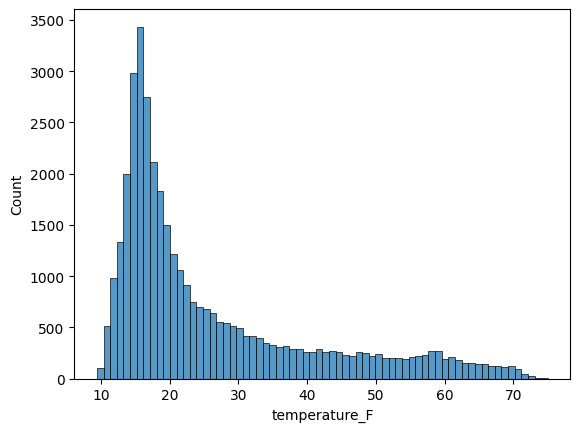

In [216]:
sns.histplot(gdf_result['temperature_F'])

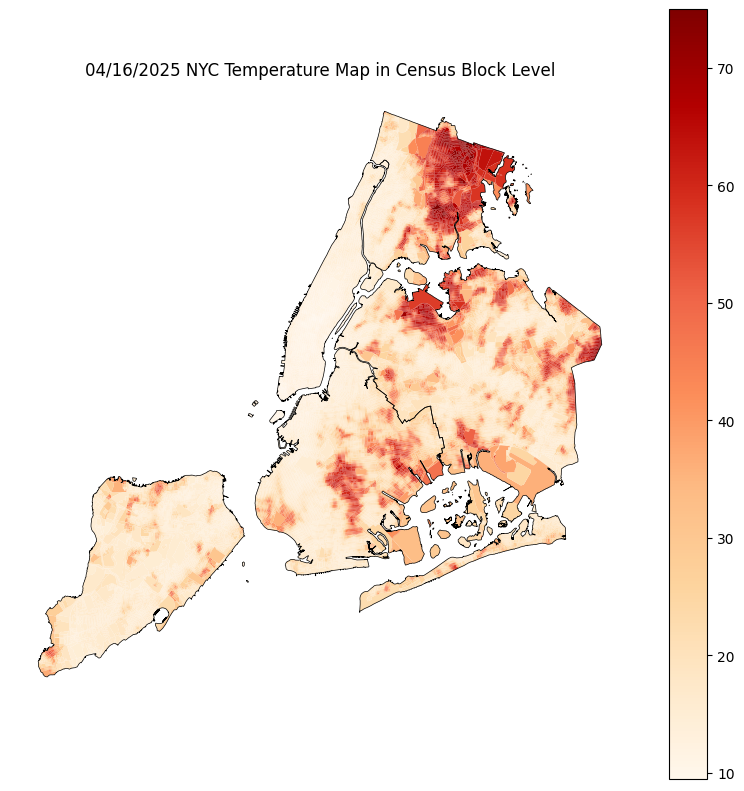

In [224]:
boundary_gdf = gpd.read_file("../USGS_Raster/Borough.geojson")
boundary_gdf = boundary_gdf.to_crs(gdf_result.crs)
boundary_gdf = boundary_gdf.buffer(0)

# 创建图像
fig, ax = plt.subplots(figsize=(10, 10))

# 温度图层
gdf_result.plot(
    column='temperature_F',
    cmap='OrRd',
    legend=True,
    ax=ax
)

# 边界图层（透明填充 + 黑色边框）
boundary_gdf.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.5
)

# 细节修饰
plt.title("04/16/2025 NYC Temperature Map in Census Block Level")
plt.axis('off')
plt.savefig('pic_1.png', dpi=300, bbox_inches='tight')
plt.show()